<a href="https://colab.research.google.com/github/pulkit-123456/Online-examination-System/blob/main/FDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:


# Correct file loading
fake = pd.read_csv("/content/Fake.csv")
real = pd.read_csv("/content/True.csv")  # ✅ FIXED

# Add labels
fake["label"] = 0
real["label"] = 1

# Combine datasets
df = pd.concat([fake, real])

# Keep only required columns
df = df[["text", "label"]]

df.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [20]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


,count
label,
0,23481
1,21417


In [21]:
# Remove nulls
df = df.dropna()

# Shuffle data
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,text,label
0,"Pew Research Center, which conducts not just d...",0
1,If this isn t white guilt on steroids and indo...,0
2,COLOMBO (Reuters) - Long delays in Sri Lanka s...,1
3,LONDON (Reuters) - U.S. Secretary of State Rex...,1
4,CLEVELAND (Reuters) - Three groups planning to...,1


In [22]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [24]:
model = LogisticRegression()

model.fit(X_train_vec, y_train)

LogisticRegression()

In [25]:
y_pred = model.predict(X_test_vec)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9856347438752784

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4694
           1       0.98      0.99      0.98      4286

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



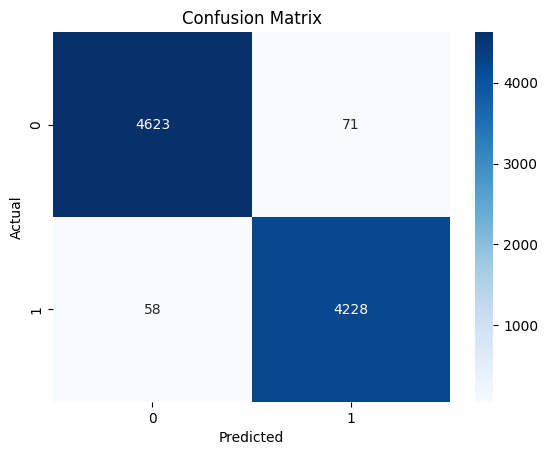

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [29]:
def predict_news(text):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    result = "REAL ✅" if pred == 1 else "FAKE ❌"
    confidence = max(prob)

    return result, confidence

# Test
news = "Breaking: Government confirms shocking secret plan"
predict_news(news)

('FAKE ❌', np.float64(0.932047803873418))

In [30]:
def highlight_words(text):
    suspicious_words = ["breaking", "shocking", "secret", "urgent", "exclusive"]
    found = [word for word in suspicious_words if word in text.lower()]
    return found

highlight_words(news)

['breaking', 'shocking', 'secret']

In [31]:
('FAKE ❌', 0.91)
['breaking', 'shocking', 'secret']

['breaking', 'shocking', 'secret']